<a href="https://colab.research.google.com/github/preethisedigar/data_analytics_projects/blob/main/Air_Pollution_Seoul_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Seoul Air Quality Analysis
The air quality data for this segment has been divided into three different csv files.

1. info.csv has the data hour by hour data about the concentration of pollutants in the air and the
status of the instruments.

2. item_info has the data for items and levels of concentration.

3. station_info has the data for measuring stations.

You can download the dataset from kaggle website: https://www.kaggle.com/datasets/bappekim/air-pollution-in-seoul

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# importing necessary libraries

import numpy as np, pandas as pd

In [ ]:
# reading the CSV files

data = pd.read_csv("Measurement_info.csv")
data.head()

,Measurement date,Station code,Item code,Average value,Instrument status
0,2017-01-01 00:00,101,1,0.004,0
1,2017-01-01 00:00,101,3,0.059,0
2,2017-01-01 00:00,101,5,1.200,0
3,2017-01-01 00:00,101,6,0.002,0
4,2017-01-01 00:00,101,8,73.000,0


In [ ]:
item = pd.read_csv("Measurement_item_info.csv")
item.head()

,Item code,Item name,Unit of measurement,Good(Blue),Normal(Green),Bad(Yellow),Very bad(Red)
0,1,SO2,ppm,0.02,0.05,0.15,1.0
1,3,NO2,ppm,0.03,0.06,0.20,2.0
2,5,CO,ppm,2.00,9.00,15.00,50.0
3,6,O3,ppm,0.03,0.09,0.15,0.5
4,8,PM10,Mircrogram/m3,30.00,80.00,150.00,600.0


In [ ]:
station = pd.read_csv("Measurement_station_info.csv")
station.head()

,Station code,Station name(district),Address,Latitude,Longitude
0,101,Jongno-gu,"19, Jong-ro 35ga-gil, Jongno-gu, Seoul, Republ...",37.572016,127.005008
1,102,Jung-gu,"15, Deoksugung-gil, Jung-gu, Seoul, Republic o...",37.564263,126.974676
2,103,Yongsan-gu,"136, Hannam-daero, Yongsan-gu, Seoul, Republic...",37.540033,127.004850
3,104,Eunpyeong-gu,"215, Jinheung-ro, Eunpyeong-gu, Seoul, Republi...",37.609823,126.934848
4,105,Seodaemun-gu,"32, Segeomjeong-ro 4-gil, Seodaemun-gu, Seoul,...",37.593742,126.949679


In [ ]:
# checking for different values
data['Item code'].value_counts()

Item code
1    647511
3    647511
5    647511
6    647511
8    647511
9    647511
Name: count, dtype: int64

In [ ]:
data.shape # shape is giving the no of rows and columns

(3885066, 5)

In [ ]:
item.shape

(6, 7)

In [ ]:
station.shape

(25, 5)

In [ ]:
sub_item = item[['Item code','Item name']]
sub_item

,Item code,Item name
0,1,SO2
1,3,NO2
2,5,CO
3,6,O3
4,8,PM10
5,9,PM2.5


In [ ]:
data_i = data.merge(sub_item, on  = 'Item code', how = 'left')
data_i.head()

,Measurement date,Station code,Item code,Average value,Instrument status,Item name
0,2017-01-01 00:00,101,1,0.004,0,SO2
1,2017-01-01 00:00,101,3,0.059,0,NO2
2,2017-01-01 00:00,101,5,1.200,0,CO
3,2017-01-01 00:00,101,6,0.002,0,O3
4,2017-01-01 00:00,101,8,73.000,0,PM10


In [ ]:
data_i.shape

(3885066, 6)

In [ ]:
# Rearrange columns
data_i.columns

Index(['Measurement date', 'Station code', 'Item code', 'Average value',
       'Instrument status', 'Item name'],
      dtype='object')

In [ ]:
data_i = data_i[['Measurement date', 'Station code', 'Item code','Item name', 'Average value',
       'Instrument status']]

In [ ]:
data_i.head()

,Measurement date,Station code,Item code,Item name,Average value,Instrument status
0,2017-01-01 00:00,101,1,SO2,0.004,0
1,2017-01-01 00:00,101,3,NO2,0.059,0
2,2017-01-01 00:00,101,5,CO,1.200,0
3,2017-01-01 00:00,101,6,O3,0.002,0
4,2017-01-01 00:00,101,8,PM10,73.000,0


In [ ]:
sub_station = station[['Station code', 'Station name(district)']]
sub_station

,Station code,Station name(district)
0,101,Jongno-gu
1,102,Jung-gu
2,103,Yongsan-gu
3,104,Eunpyeong-gu
4,105,Seodaemun-gu
5,106,Mapo-gu
6,107,Seongdong-gu
7,108,Gwangjin-gu
8,109,Dongdaemun-gu
9,110,Jungnang-gu


In [ ]:
data_i = data_i.merge(sub_station, on = 'Station code', how = 'left')
data_i .head()

,Measurement date,Station code,Item code,Item name,Average value,Instrument status,Station name(district)
0,2017-01-01 00:00,101,1,SO2,0.004,0,Jongno-gu
1,2017-01-01 00:00,101,3,NO2,0.059,0,Jongno-gu
2,2017-01-01 00:00,101,5,CO,1.200,0,Jongno-gu
3,2017-01-01 00:00,101,6,O3,0.002,0,Jongno-gu
4,2017-01-01 00:00,101,8,PM10,73.000,0,Jongno-gu


In [ ]:
data_i = data_i[['Measurement date', 'Station code', 'Station name(district)','Item code','Item name', 'Average value',
       'Instrument status']]

data_i.head()

,Measurement date,Station code,Station name(district),Item code,Item name,Average value,Instrument status
0,2017-01-01 00:00,101,Jongno-gu,1,SO2,0.004,0
1,2017-01-01 00:00,101,Jongno-gu,3,NO2,0.059,0
2,2017-01-01 00:00,101,Jongno-gu,5,CO,1.200,0
3,2017-01-01 00:00,101,Jongno-gu,6,O3,0.002,0
4,2017-01-01 00:00,101,Jongno-gu,8,PM10,73.000,0


In [ ]:
# drop function , drops the columns which is not needed for analysis

data_i = data_i.drop(['Station code','Item code'], axis = 1)
data_i.head()

,Measurement date,Station name(district),Item name,Average value,Instrument status
0,2017-01-01 00:00,Jongno-gu,SO2,0.004,0
1,2017-01-01 00:00,Jongno-gu,NO2,0.059,0
2,2017-01-01 00:00,Jongno-gu,CO,1.200,0
3,2017-01-01 00:00,Jongno-gu,O3,0.002,0
4,2017-01-01 00:00,Jongno-gu,PM10,73.000,0


In [ ]:
# check for null values in the main table that is data_i
data_i.isnull().sum()

Measurement date          0
Station name(district)    0
Item name                 0
Average value             0
Instrument status         0
dtype: int64

In [ ]:
data_i['Instrument status'].value_counts()

Instrument status
0    3775778
8      32341
1      29717
4      22752
9      20490
2       3988
Name: count, dtype: int64

### Meanings of Instrument Status

1. 0 = Normal
2. 1 = Need for Calibration
3. 2 = Abnormal
4. 4 = Power cut off
5. 8 = Under repair
6. 9 = Abnormal data

In [ ]:
status = {'Instrument status': [0,1,2,4,8,9], 'Status': ['Normal','Need for Calibration','Abnormal','Power cut off',' Under repair','Abnormal data']}
status

{'Instrument status': [0, 1, 2, 4, 8, 9],
 'Status': ['Normal',
  'Need for Calibration',
  'Abnormal',
  'Power cut off',
  ' Under repair',
  'Abnormal data']}

In [ ]:
status = pd.DataFrame(status)
status

,Instrument status,Status
0,0,Normal
1,1,Need for Calibration
2,2,Abnormal
3,4,Power cut off
4,8,Under repair
5,9,Abnormal data


In [ ]:
data_i = data_i.merge(status, on = 'Instrument status', how = 'left')
data_i.head()

,Measurement date,Station name(district),Item name,Average value,Instrument status,Status
0,2017-01-01 00:00,Jongno-gu,SO2,0.004,0,Normal
1,2017-01-01 00:00,Jongno-gu,NO2,0.059,0,Normal
2,2017-01-01 00:00,Jongno-gu,CO,1.200,0,Normal
3,2017-01-01 00:00,Jongno-gu,O3,0.002,0,Normal
4,2017-01-01 00:00,Jongno-gu,PM10,73.000,0,Normal


In [ ]:
data_i = data_i.drop(['Instrument status'], axis = 1)
data_i.head()

,Measurement date,Station name(district),Item name,Average value,Status
0,2017-01-01 00:00,Jongno-gu,SO2,0.004,Normal
1,2017-01-01 00:00,Jongno-gu,NO2,0.059,Normal
2,2017-01-01 00:00,Jongno-gu,CO,1.200,Normal
3,2017-01-01 00:00,Jongno-gu,O3,0.002,Normal
4,2017-01-01 00:00,Jongno-gu,PM10,73.000,Normal


In [ ]:
data_i['Year'] = pd.to_datetime(data_i['Measurement date']).dt.year
data_i['Month'] = pd.to_datetime(data_i['Measurement date']).dt.month
data_i['Date'] = pd.to_datetime(data_i['Measurement date']).dt.day
data_i['Hour'] = pd.to_datetime(data_i['Measurement date']).dt.hour
data_i.head()

,Measurement date,Station name(district),Item name,Average value,Status,Year,Month,Date,Hour
0,2017-01-01 00:00,Jongno-gu,SO2,0.004,Normal,2017,1,1,0
1,2017-01-01 00:00,Jongno-gu,NO2,0.059,Normal,2017,1,1,0
2,2017-01-01 00:00,Jongno-gu,CO,1.200,Normal,2017,1,1,0
3,2017-01-01 00:00,Jongno-gu,O3,0.002,Normal,2017,1,1,0
4,2017-01-01 00:00,Jongno-gu,PM10,73.000,Normal,2017,1,1,0


In [ ]:
data_i = data_i.drop(['Measurement date'], axis = 1)
data_i.head()

,Station name(district),Item name,Average value,Status,Year,Month,Date,Hour
0,Jongno-gu,SO2,0.004,Normal,2017,1,1,0
1,Jongno-gu,NO2,0.059,Normal,2017,1,1,0
2,Jongno-gu,CO,1.200,Normal,2017,1,1,0
3,Jongno-gu,O3,0.002,Normal,2017,1,1,0
4,Jongno-gu,PM10,73.000,Normal,2017,1,1,0


In [ ]:
data_i['Hour'].value_counts()

Hour
8     162270
6     162246
7     162228
9     162198
11    162150
16    162000
13    162000
12    162000
17    162000
20    161994
19    161994
5     161946
22    161946
15    161850
10    161844
21    161730
14    161700
18    161694
23    161646
4     161646
2     161646
1     161496
3     161496
0     161346
Name: count, dtype: int64

In [ ]:
data_i.tail()

,Station name(district),Item name,Average value,Status,Year,Month,Date,Hour
3885061,Gangnam-gu,PM2.5,13.000,Normal,2019,12,31,23
3885062,Geumcheon-gu,PM2.5,24.000,Normal,2019,12,31,23
3885063,Seodaemun-gu,PM10,19.000,Normal,2019,12,31,23
3885064,Gangdong-gu,NO2,0.037,Normal,2019,12,31,23
3885065,Gwangjin-gu,NO2,0.030,Normal,2019,12,31,23


In [ ]:
data_i['Year'].value_counts()

Year
2017    1314000
2018    1314000
2019    1257066
Name: count, dtype: int64

In [ ]:
# Groupby functions


table = data_i.groupby(['Station name(district)','Item name'])['Average value'].mean()
print(table)

Station name(district)  Item name
Dobong-gu               CO            0.572814
                        NO2           0.018949
                        O3            0.023604
                        PM10         43.294415
                        PM2.5        25.733277
                                       ...    
Yongsan-gu              NO2           0.021777
                        O3            0.013814
                        PM10         35.539183
                        PM2.5        23.670437
                        SO2          -0.004278
Name: Average value, Length: 150, dtype: float64


In [ ]:
# to display all the rows and columns for the output data
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Groupby function to aggregate the overall data_i information
table = data_i.groupby(['Station name(district)','Item name'])['Average value'].mean().reset_index()
table

,Station name(district),Item name,Average value
0,Dobong-gu,CO,0.572814
1,Dobong-gu,NO2,0.018949
2,Dobong-gu,O3,0.023604
3,Dobong-gu,PM10,43.294415
4,Dobong-gu,PM2.5,25.733277
5,Dobong-gu,SO2,0.000913
6,Dongdaemun-gu,CO,0.490542
7,Dongdaemun-gu,NO2,0.009495
8,Dongdaemun-gu,O3,0.002446
9,Dongdaemun-gu,PM10,38.269958


In [ ]:
pivot = data_i.pivot_table(index = 'Status', columns = 'Station name(district)', values = 'Average value', aggfunc = ['sum','median'])
pivot.T # T is helping you transpose the output data

Status                          Under repair     Abnormal  Abnormal data  \
       Station name(district)                                              
sum    Dobong-gu                   1889.9250    1069.0000    171800.6180   
       Dongdaemun-gu                524.2790      60.9120      7038.8070   
       Dongjak-gu                  1658.6320    1488.5110      9473.0860   
       Eunpyeong-gu                 126.0490   35383.0000     29946.3640   
       Gangbuk-gu                   151.1460          NaN      3650.3760   
       Gangdong-gu                  113.4400    1130.3170     36667.4970   
       Gangnam-gu                 12255.1840    2074.0910     11849.0770   
       Gangseo-gu                181895.9030    1554.9000    132683.5160   
       Geumcheon-gu                 126.4020       0.0000      5181.8080   
       Guro-gu                    11054.7430   31509.0000    395074.3960   
       Gwanak-gu                    121.5480   50555.4150     76670.0990   
       Gwangjin-gu                 5790.1740   41667.7000    235028.1750   
       Jongno-gu                    134.8550    4639.4000     10683.5390   
       Jung-gu                           NaN     -14.3920      4840.9890   
       Jungnang-gu                  585.2020     210.9940     12759.5420   
       Mapo-gu                     1107.0490  152619.0000     95270.0920   
       Nowon-gu                      45.5810    1260.0100      3171.9740   
       Seocho-gu                   9737.1210  287894.0000    163244.2030   
       Seodaemun-gu                1568.6320      52.6000     43194.8540   
       Seongbuk-gu                12517.9140   24840.6350    122769.8790   
       Seongdong-gu                2179.7950  126074.4190     65080.7930   
       Songpa-gu                   5249.7000      33.0000    156584.7730   
       Yangcheon-gu                   1.1050     102.2850      9557.6380   
       Yeongdeungpo-gu             2527.9430   91607.8190    137440.8800   
       Yongsan-gu                 12934.0820    2018.2760     23378.2590   
median Dobong-gu                      0.0000      44.0000         1.2000   
       Dongdaemun-gu                  0.0010       0.0000        16.5000   
       Dongjak-gu                     0.0000      -1.0000        33.0000   
       Eunpyeong-gu                   0.9000      -1.0000        19.0000   
       Gangbuk-gu                     0.0000          NaN         0.1000   
       Gangdong-gu                    0.0180       0.0115        23.0000   
       Gangnam-gu                     0.0170       9.0000        25.0000   
       Gangseo-gu                     0.0000       5.0000        25.0000   
       Geumcheon-gu                  -0.4935       0.0000        19.5000   
       Guro-gu                        0.0000      42.0000        35.0000   
       Gwanak-gu                      0.0000       0.0040        32.0000   
       Gwangjin-gu                    0.0000       0.0000         0.9000   
       Jongno-gu                      0.0010       8.0000        27.0000   
       Jung-gu                           NaN       0.0055        24.0000   
       Jungnang-gu                    0.0010       0.0470        10.0000   
       Mapo-gu                        0.0010     985.0000        16.0000   
       Nowon-gu                       0.0000      21.0000         0.0145   
       Seocho-gu                      0.0000     985.0000        23.0000   
       Seodaemun-gu                   0.0000       3.0000         8.0000   
       Seongbuk-gu                    0.0000       0.0010        22.0000   
       Seongdong-gu                   0.0900       0.9000        33.0000   
       Songpa-gu                     50.0000       3.0000        28.0000   
       Yangcheon-gu                   0.0000       0.0010        35.5000   
       Yeongdeungpo-gu                0.0000       0.0000        30.0000   
       Yongsan-gu                    -1.0000       0.0020        24.0000   

Status                         Need for Calibra

In [ ]:
pivot = data_i.pivot_table(index = ['Status','Year'], columns = 'Station name(district)', values = 'Average value', aggfunc = ['sum','median'])
pivot.T # T is helping you transpose the output data

Status                         Under repair                      Abnormal  \
Year                                   2017       2018     2019      2017   
       Station name(district)                                               
sum    Dobong-gu                   493.4730   1396.452      NaN  1069.000   
       Dongdaemun-gu               235.1280     45.543  243.608       NaN   
       Dongjak-gu                 1658.6310      0.001      NaN  1015.500   
       Eunpyeong-gu                115.9630     22.086  -12.000   -21.000   
       Gangbuk-gu                  151.1460        NaN      NaN       NaN   
       Gangdong-gu                 107.1170      6.323      NaN     0.016   
       Gangnam-gu                12056.0150        NaN  199.169   655.018   
       Gangseo-gu               181895.9030        NaN      NaN  1546.000   
       Geumcheon-gu                126.4020        NaN      NaN       NaN   
       Guro-gu                     156.0000  10112.743  786.000    -7.000   
       Gwanak-gu                     0.9150     14.149  106.484   306.100   
       Gwangjin-gu                  33.0000   5721.974   35.200   257.000   
       Jongno-gu                   140.6600     -5.805      NaN       NaN   
       Jung-gu                          NaN        NaN      NaN       NaN   
       Jungnang-gu                 136.6810    108.005  340.516       NaN   
       Mapo-gu                     884.7230      0.188  222.138       NaN   
       Nowon-gu                     45.0000      0.564    0.017       NaN   
       Seocho-gu                   117.8330   9619.288      NaN       NaN   
       Seodaemun-gu                379.4850   1189.147      NaN    54.600   
       Seongbuk-gu                 851.1920  11666.722      NaN  4156.296   
       Seongdong-gu               2067.3440    112.451      NaN       NaN   
       Songpa-gu                    85.7000   5164.000      NaN    33.000   
       Yangcheon-gu                  0.0230      1.082    0.000   102.261   
       Yeongdeungpo-gu             553.9730   1973.970      NaN     1.776   
       Yongsan-gu                    0.1280  12933.954      NaN    59.168   
median Dobong-gu                     0.0000      0.000      NaN    48.500   
       Dongdaemun-gu                 0.0000      0.000    0.001       NaN   
       Dongjak-gu                    0.0000      0.001      NaN    66.000   
       Eunpyeong-gu                  1.0000      0.008   -1.000    -1.000   
       Gangbuk-gu                    0.0000        NaN      NaN       NaN   
       Gangdong-gu                   0.0000      0.020      NaN     0.004   
       Gangnam-gu                    0.0000        NaN    0.023     5.000   
       Gangseo-gu                    0.0000        NaN      NaN     5.000   
       Geumcheon-gu                 -0.4935        NaN      NaN       NaN   
       Guro-gu                       0.0000      0.000   40.500    -1.000   
       Gwanak-gu                     0.0000      0.000    0.000     0.000   
       Gwangjin-gu                   1.0000      0.000    1.150     7.000   
       Jongno-gu                     0.0000      0.001      NaN       NaN   
       Jung-gu                          NaN        NaN      NaN       NaN   
       Jungnang-gu                   0.0000      0.000    0.002       NaN   
       Mapo-gu                       0.0000      0.000    0.002       NaN   
       Nowon-gu                      0.0000      0.000    0.000       NaN   
       Seocho-gu                     0.0000      0.000      NaN       NaN   
       Seodaemun-gu                  0.0000      0.000      NaN     3.000   
       Seongbuk-gu                  -1.0000      0.002      NaN     0.614   
       Seongdong-gu                  9.5000      0.000      NaN       NaN   
       Songpa-gu                     3.0000     59.000      NaN     3.000   
       Yangcheon-gu                  0.0000      0.014    0.000     0.001   
       Yeongdeungpo-gu               0.0000      0.000      NaN     0.000

In [ ]:
pivot = data_i.pivot_table(index = ['Status','Year','Month'], columns = 'Station name(district)', values = 'Average value', aggfunc = ['sum','median'])
pivot.T # T is helping you transpose the output data

Status                         Under repair                                  \
Year                                   2017                                   
Month                                    1         2          3          4    
       Station name(district)                                                 
sum    Dobong-gu                   433.0000       NaN        NaN    16.0000   
       Dongdaemun-gu                    NaN    0.6470    131.481        NaN   
       Dongjak-gu                       NaN       NaN        NaN        NaN   
       Eunpyeong-gu                 79.3630   36.6000        NaN        NaN   
       Gangbuk-gu                       NaN       NaN        NaN        NaN   
       Gangdong-gu                      NaN       NaN        NaN        NaN   
       Gangnam-gu                       NaN  754.6540  10677.061   589.3000   
       Gangseo-gu                    0.0000       NaN    599.000     0.0000   
       Geumcheon-gu                     NaN  132.4020        NaN        NaN   
       Guro-gu                          NaN       NaN        NaN   156.0000   
       Gwanak-gu                        NaN       NaN      0.915        NaN   
       Gwangjin-gu                      NaN       NaN        NaN    33.0000   
       Jongno-gu                        NaN       NaN        NaN        NaN   
       Jung-gu                          NaN       NaN        NaN        NaN   
       Jungnang-gu                      NaN       NaN    136.681        NaN   
       Mapo-gu                          NaN    0.0000      1.112   718.6110   
       Nowon-gu                         NaN       NaN        NaN        NaN   
       Seocho-gu                        NaN       NaN        NaN    72.0000   
       Seodaemun-gu                     NaN       NaN        NaN   108.0000   
       Seongbuk-gu                 -16.9250       NaN    786.000        NaN   
       Seongdong-gu                     NaN       NaN        NaN  1046.0000   
       Songpa-gu                        NaN       NaN        NaN        NaN   
       Yangcheon-gu                     NaN       NaN        NaN     0.0230   
       Yeongdeungpo-gu                  NaN       NaN     41.673   219.0000   
       Yongsan-gu                       NaN       NaN        NaN        NaN   
median Dobong-gu                     0.7000       NaN        NaN     0.0000   
       Dongdaemun-gu                    NaN    0.0000      0.000        NaN   
       Dongjak-gu                       NaN       NaN        NaN        NaN   
       Eunpyeong-gu                  0.1745    1.0000        NaN        NaN   
       Gangbuk-gu                       NaN       NaN        NaN        NaN   
       Gangdong-gu                      NaN       NaN        NaN        NaN   
       Gangnam-gu                       NaN    0.0000      0.000     2.7000   
       Gangseo-gu                    0.0000       NaN     31.500     0.0000   
       Geumcheon-gu                     NaN    0.6545        NaN        NaN   
       Guro-gu                          NaN       NaN        NaN     0.0000   
       Gwanak-gu                        NaN       NaN      0.000        NaN   
       Gwangjin-gu                      NaN       NaN        NaN     1.0000   
       Jongno-gu                        NaN       NaN        NaN        NaN   
       Jung-gu                          NaN       NaN        NaN        NaN   
       Jungnang-gu                      NaN       NaN      0.000        NaN   
       Mapo-gu                          NaN    0.0000      0.000    29.0000   
       Nowon-gu                         NaN       NaN        NaN        NaN   
       Seocho-gu                        NaN       NaN        NaN     0.0000   
       Seodaemun-gu                     NaN       NaN        NaN     0.0000   
       Seongbuk-gu                   0.0000       NaN     56.500        NaN   
       Seongdong-gu                     NaN       NaN        NaN     0.0000   
       Songpa-gu                        NaN       

### Working with Seaborn

In [ ]:
import matplotlib.pyplot as plt,seaborn as sns

In [ ]:
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


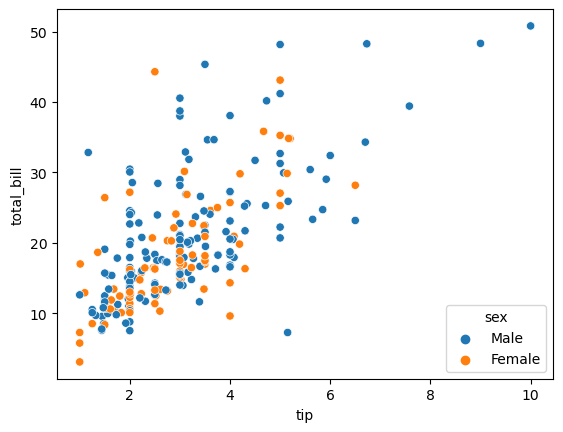

In [ ]:
sns.scatterplot(data = tips, x = 'tip',y= 'total_bill', hue = 'sex')
plt.show()

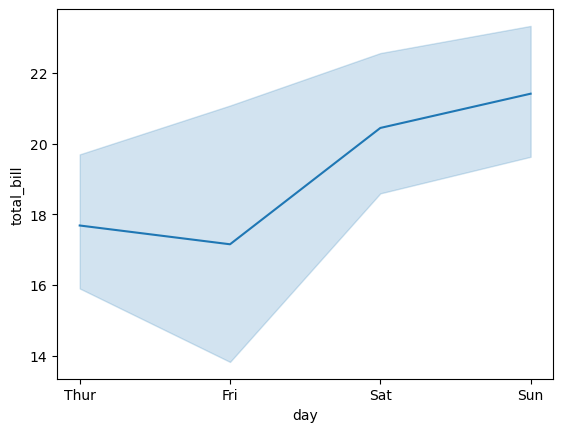

In [ ]:
sns.lineplot(data = tips, x = 'day', y = 'total_bill')
plt.show()

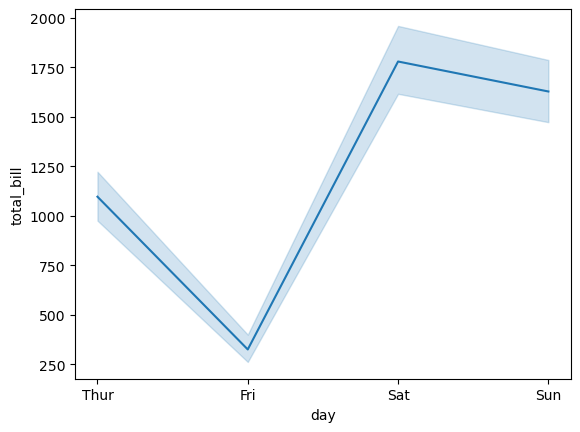

In [ ]:
sns.lineplot(data = tips, x = 'day', y = 'total_bill', estimator = 'sum')
plt.show()

<Axes: xlabel='day', ylabel='tip'>

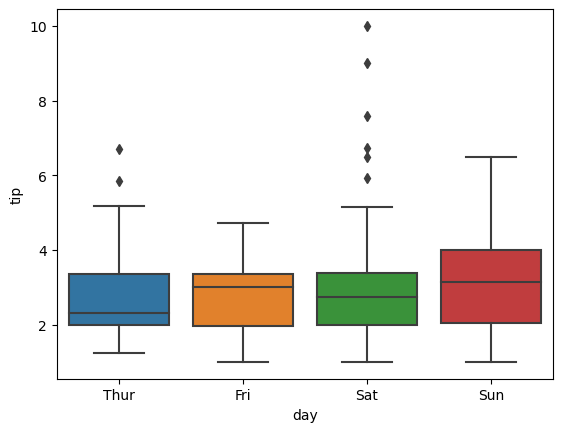

In [ ]:
sns.boxplot(data = tips, x = 'day', y = 'tip')

<Axes: xlabel='day', ylabel='tip'>

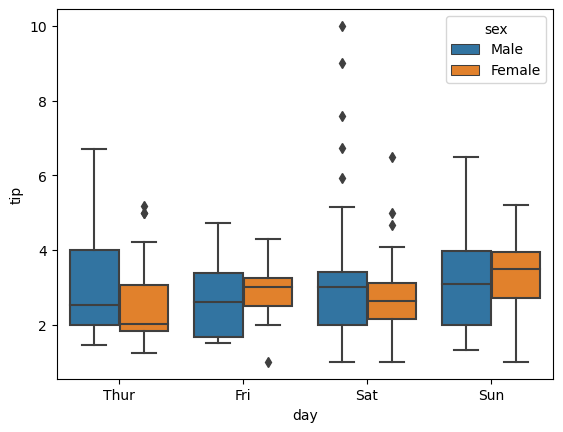

In [ ]:
sns.boxplot(data = tips, x = 'day', y = 'tip', hue = 'sex')

<Axes: xlabel='day', ylabel='total_bill'>

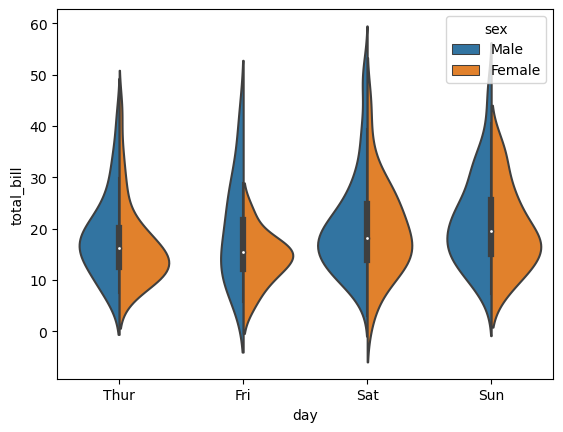

In [ ]:
# spread of the datapoints
sns.violinplot(data = tips, x = 'day', y = 'total_bill', hue = 'sex', split = True)

<Axes: xlabel='day', ylabel='total_bill'>

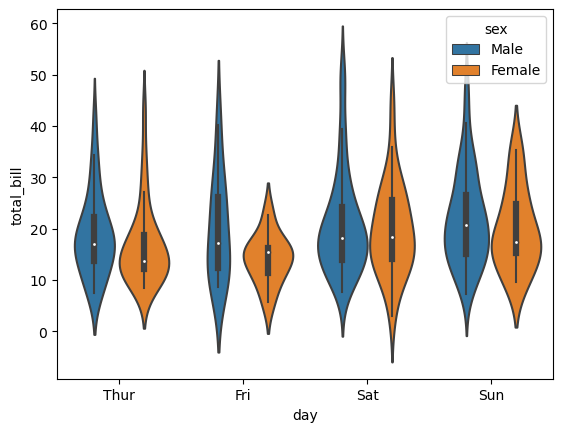

In [ ]:
sns.violinplot(data = tips, x = 'day', y = 'total_bill', hue = 'sex')

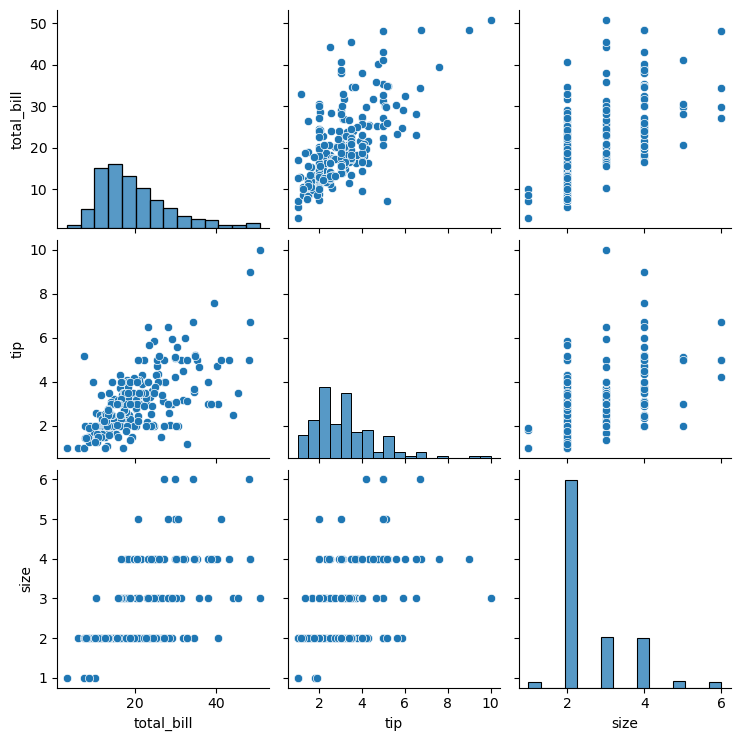

In [ ]:
# pairplots uses numerical columns from your dataset

import warnings
warnings.filterwarnings('ignore')
sns.pairplot(tips)
plt.show()

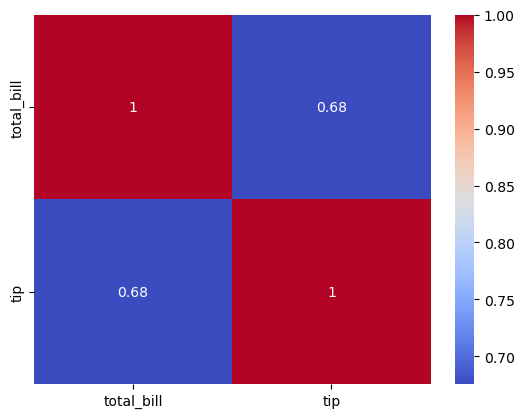

In [ ]:
tips = tips[['total_bill','tip']]
sns.heatmap(tips.corr(), annot = True, cmap = "coolwarm")
plt.show()

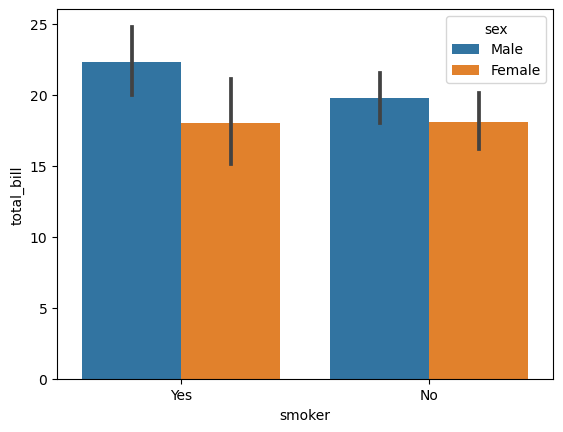

In [ ]:
tips = sns.load_dataset('tips')
sns.barplot(data=tips, x='smoker', y='total_bill', hue = 'sex')
plt.show()

<Axes: xlabel='day', ylabel='count'>

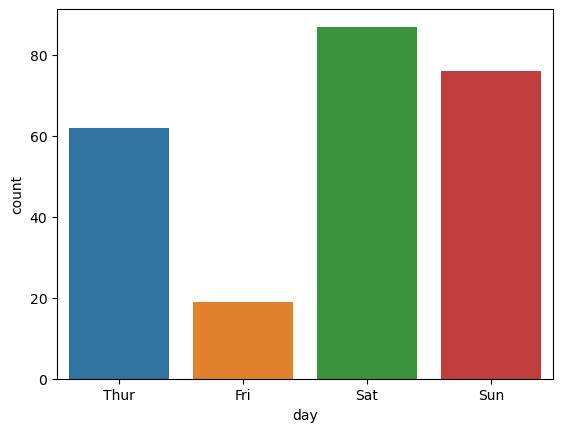

In [ ]:
sns.countplot(data = tips, x = 'day') # frequency

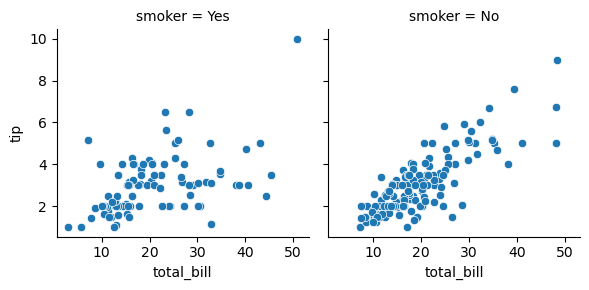

In [ ]:
g = sns.FacetGrid(tips, col = 'smoker')
g.map(sns.scatterplot, 'total_bill', 'tip')
plt.show()

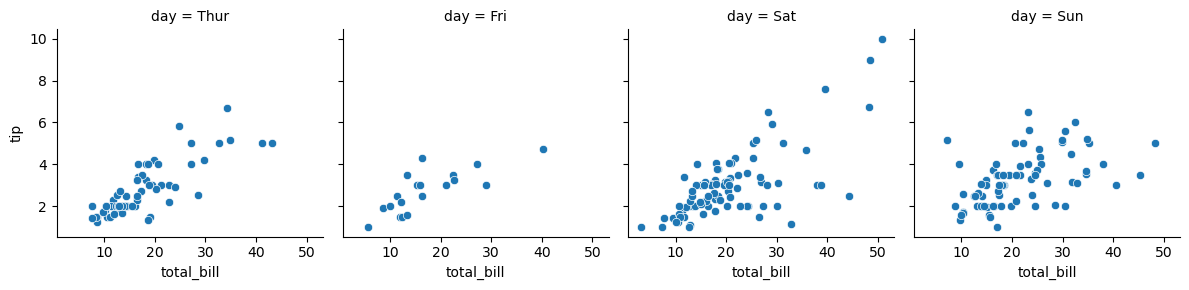

In [ ]:
g = sns.FacetGrid(tips, col = 'day')
g.map(sns.scatterplot, 'total_bill', 'tip')
plt.show()

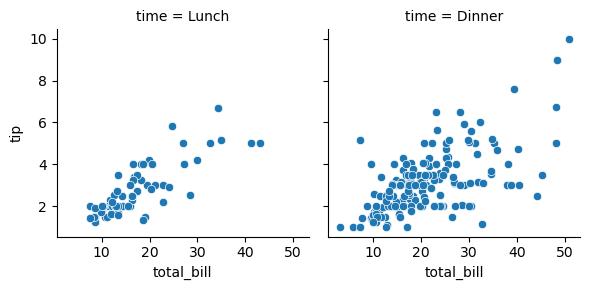

In [ ]:
g = sns.FacetGrid(tips, col = 'time')
g.map(sns.scatterplot, 'total_bill', 'tip')
plt.show()

<Axes: xlabel='total_bill', ylabel='Count'>

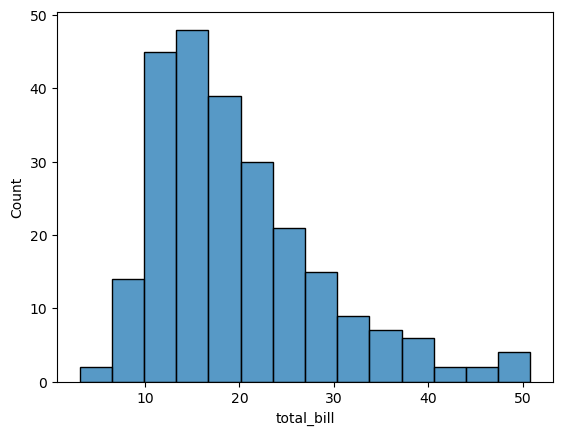

In [ ]:
sns.histplot(data = tips, x = 'total_bill')

<Axes: xlabel='total_bill', ylabel='Count'>

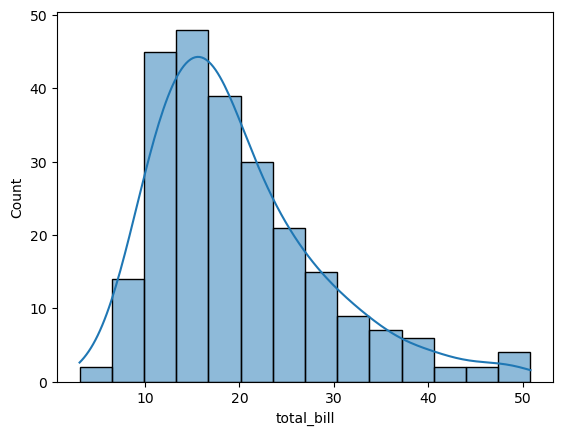

In [ ]:
sns.histplot(data = tips, x = 'total_bill', kde = True)

<Axes: xlabel='total_bill', ylabel='tip'>

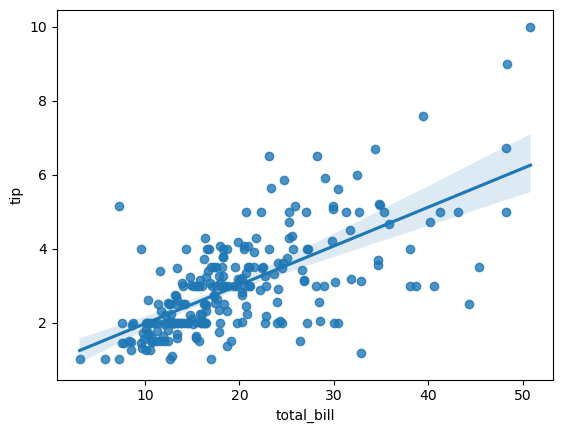

In [ ]:
# this uses y = beta0 + beta1x1 ---> straight line formula
sns.regplot(data = tips, x = 'total_bill', y = 'tip')

<Axes: xlabel='total_bill', ylabel='tip'>

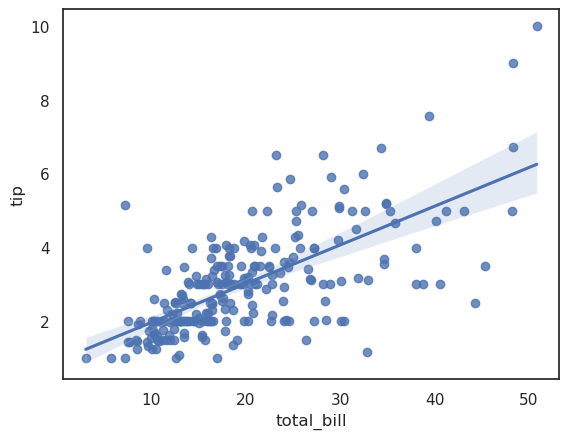

In [ ]:
sns.set(style = 'white')
sns.regplot(data = tips, x = 'total_bill', y = 'tip')

<Axes: xlabel='total_bill', ylabel='tip'>

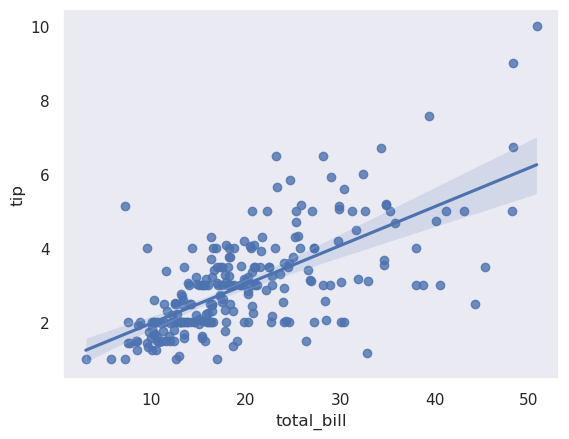

In [ ]:
sns.set(style = 'dark')
sns.regplot(data = tips, x = 'total_bill', y = 'tip')

<Axes: xlabel='total_bill', ylabel='tip'>

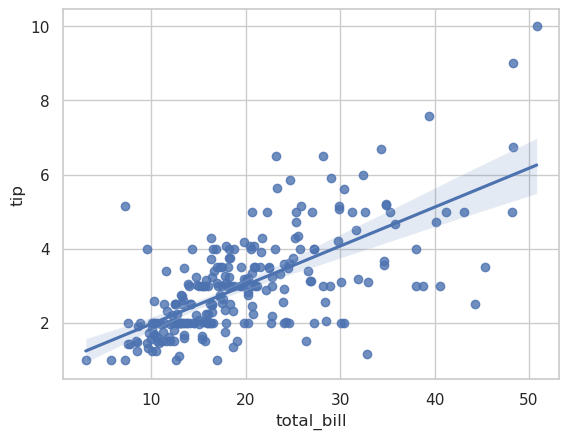

In [ ]:
sns.set(style = 'whitegrid')
sns.regplot(data = tips, x = 'total_bill', y = 'tip')

<Axes: xlabel='total_bill', ylabel='tip'>

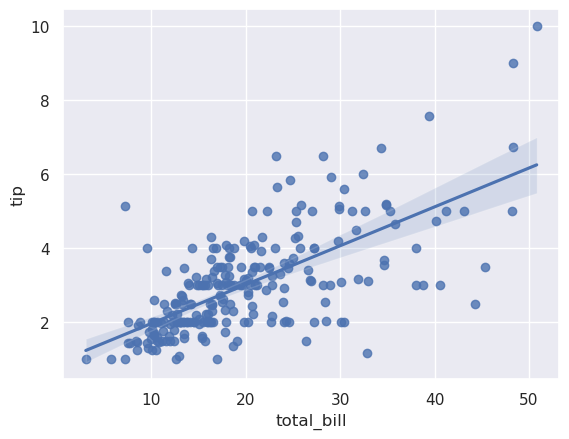

In [ ]:
sns.set(style = 'darkgrid')
sns.regplot(data = tips, x = 'total_bill', y = 'tip')

<Axes: xlabel='total_bill', ylabel='tip'>

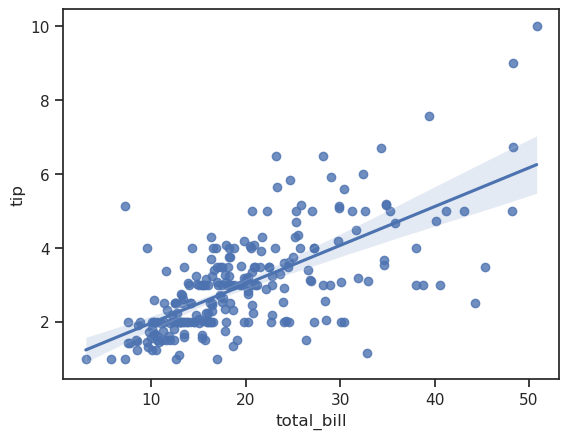

In [ ]:
sns.set(style = 'ticks')
sns.regplot(data = tips, x = 'total_bill', y = 'tip')

<Axes: xlabel='total_bill', ylabel='tip'>

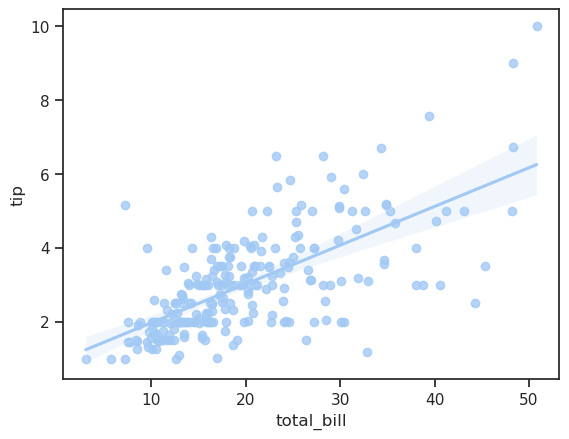

In [ ]:
sns.set_palette('pastel')
sns.regplot(data = tips, x = 'total_bill', y = 'tip')

<Axes: xlabel='total_bill', ylabel='tip'>

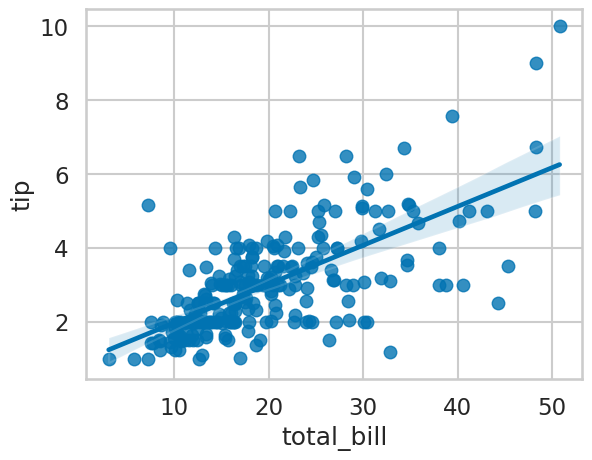

In [ ]:
sns.set(style = 'whitegrid', context = 'talk', palette = 'colorblind')
sns.regplot(data = tips, x = 'total_bill', y = 'tip')

<Axes: xlabel='total_bill', ylabel='Count'>

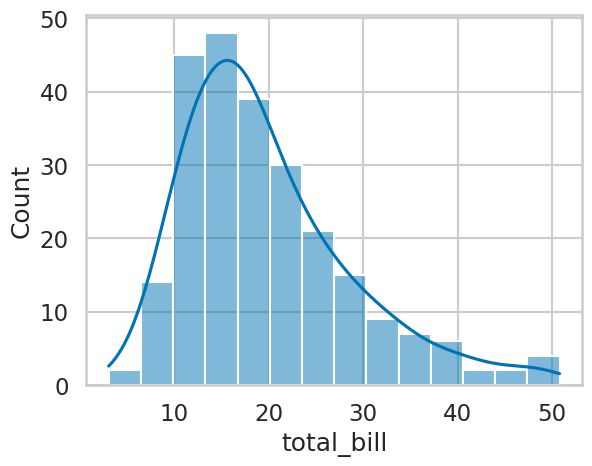

In [ ]:
sns.histplot(data = tips, x = 'total_bill', kde = True)

<Axes: xlabel='day', ylabel='count'>

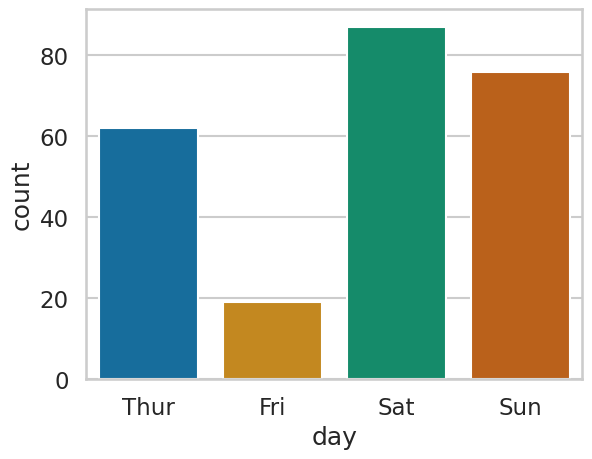

In [ ]:
sns.countplot(data = tips, x = 'day') # frequency

In [ ]:
# reset back to your default setting
sns.reset_defaults()

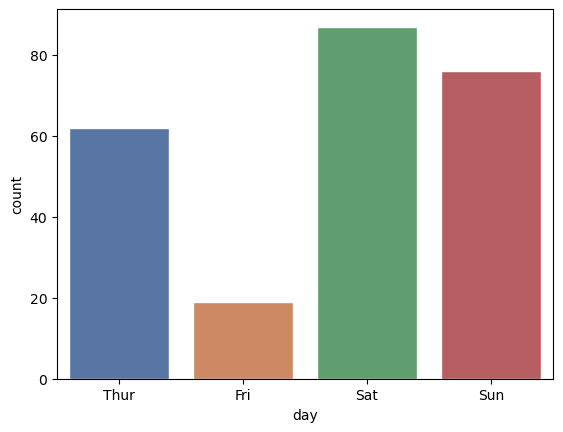

In [ ]:
sns.set_theme(style="whitegrid")
sns.countplot(data = tips, x = 'day') # frequency
plt.show()

In [ ]:
help(sns.set)

Help on function set in module seaborn.rcmod:

set(*args, **kwargs)
    Alias for :func:`set_theme`, which is the preferred interface.
    
    This function may be removed in the future.

